# Chronological operation, commitment, and offshore benchmark

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/energy_networks/04_time_series_commitment_offshore_benchmark.ipynb)

This notebook demonstrates chronological profiles, integrated energy/cost/emissions KPIs, generator commitment constraints, and the reproducible offshore wind–gas benchmark.

**Release requirement:** NeqSim 3.17.0 or later.\n\n**Implementation history:** PRs #2614, #2617, and #2618.
**Validated environment:** stored outputs use NeqSim 3.17.0, Python 3.12.13, and OpenJDK 17.0.19.


## 1. Setup

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
):
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.17.0",
        ],
        check=True,
    )

from neqsim import jneqsim
from jpype import JClass

neqsim_version = importlib.metadata.version("neqsim")
if neqsim_version != "3.17.0":
    raise RuntimeError(
        "This stored-output example was validated with NeqSim 3.17.0; " f"found {neqsim_version}."
    )
print(f"NeqSim {neqsim_version} loaded from the public Python package")


NeqSim 3.17.0 loaded from the public Python package


In [2]:
EnergyTimeSeriesProfile = jneqsim.process.equipment.energy.EnergyTimeSeriesProfile
EnergyTimeSeriesSimulator = jneqsim.process.equipment.energy.EnergyTimeSeriesSimulator
CommittedEnergyGenerator = jneqsim.process.equipment.energy.CommittedEnergyGenerator
OffshoreEnergyReferenceCase = jneqsim.process.equipment.energy.OffshoreEnergyReferenceCase
EnergyBus = jneqsim.process.equipment.stream.EnergyBus
EnergyPort = jneqsim.process.equipment.stream.EnergyPort
EnergyType = jneqsim.process.equipment.stream.EnergyType
EnergyPortDirection = jneqsim.process.equipment.stream.EnergyPortDirection
EnergyPortMode = jneqsim.process.equipment.stream.EnergyPortMode
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
UUID = JClass("java.util.UUID")


## 2. Run the published offshore benchmark

In [3]:
result = OffshoreEnergyReferenceCase.run24HourCase()
print(result.toJson())


{
  "intervals": [
    {
      "intervalIndex": 0,
      "startTimeSeconds": 0.0,
      "durationSeconds": 14400.0,
      "networkReports": [
        {
          "busName": "offshore electrical bus",
          "allocations": [
            {
              "participantId": "0db1517a-1764-4c06-a663-a9b012120132",
              "participantName": "offshore wind.power",
              "mode": "CALCULATED",
              "direction": "OUTPUT",
              "priority": 0,
              "requestedPower": 2000000.0,
              "allocatedPower": 2000000.0,
              "unmetPower": 0.0,
              "curtailedPower": 0.0
            },
            {
              "participantId": "712de50a-bdfe-4782-ae9c-0a44a5634499",
              "participantName": "gas turbine generation.power",
              "mode": "CALCULATED",
              "direction": "OUTPUT",
              "priority": 10,
              "requestedPower": 1.5E7,
              "allocatedPower": 9000000.0,
              "unmetPower

In [4]:
import pandas as pd

interval_rows = []
for interval in result.getIntervals():
    report = interval.getNetworkReports().get(0)
    allocations = {
        a.getParticipantName(): a.getAllocatedPower() / 1e6 for a in report.getAllocations()
    }
    interval_rows.append(
        {
            "start_h": interval.getStartTimeSeconds() / 3600.0,
            "duration_h": interval.getDurationSeconds() / 3600.0,
            "served_MW": report.getServedDemand() / 1e6,
            "unmet_MW": report.getUnmetDemand() / 1e6,
            "curtailed_MW": report.getCurtailedSupply() / 1e6,
            "wind_MW": allocations.get("offshore wind.power", 0.0),
            "gas_MW": allocations.get("gas turbine generation.power", 0.0),
            "critical_MW": allocations.get("critical process load.power", 0.0),
            "flexible_MW": allocations.get("flexible process load.power", 0.0),
            "cost_per_h": report.getOperatingCostPerHour(),
            "co2_kg_per_h": report.getCo2EmissionRate(),
        }
    )
interval_df = pd.DataFrame(interval_rows)
interval_df


Out[4]: 
   start_h  duration_h  served_MW  ...  flexible_MW  cost_per_h  co2_kg_per_h
0      0.0         4.0       11.0  ...          3.0       810.0        4050.0
1      4.0         4.0       13.0  ...          4.0       630.0        3150.0
2      8.0         4.0       15.0  ...          5.0         0.0           0.0
3     12.0         4.0       15.0  ...          4.0       630.0        3150.0
4     16.0         4.0       13.0  ...          3.0       810.0        4050.0
5     20.0         4.0       11.0  ...          2.0       900.0        4500.0

[6 rows x 11 columns]


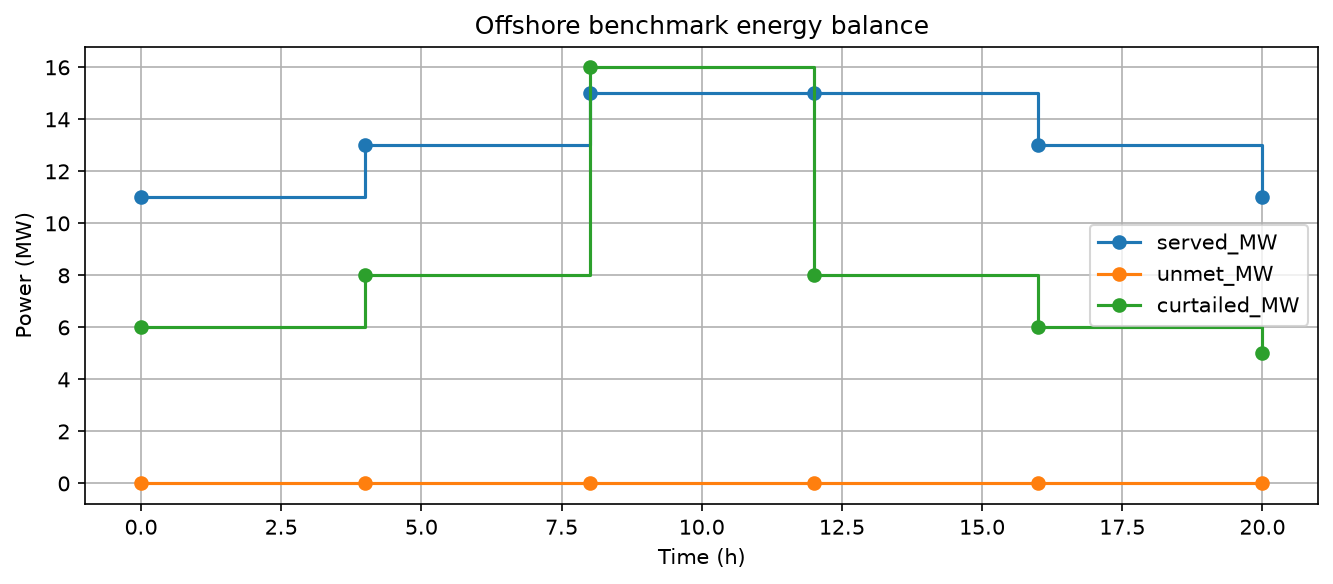

In [5]:
import matplotlib.pyplot as plt

ax = interval_df.plot(
    x="start_h",
    y=["served_MW", "unmet_MW", "curtailed_MW"],
    drawstyle="steps-post",
    marker="o",
    figsize=(9, 4),
)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Power (MW)")
ax.set_title("Offshore benchmark energy balance")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** The reference case serves all demand while producing deliberate wind curtailment in one interval. The fixed result is intended for regression and audit.

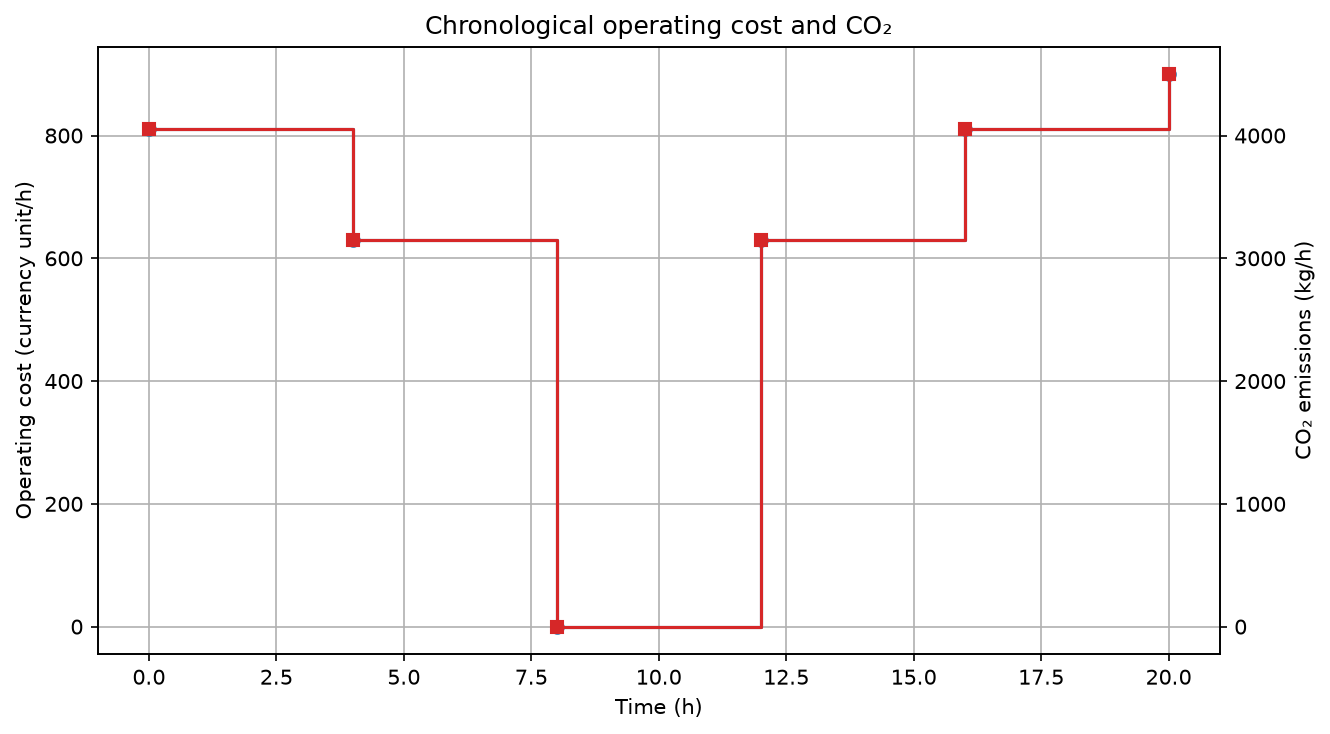

In [6]:
ax = interval_df.plot(
    x="start_h",
    y="cost_per_h",
    color="tab:blue",
    drawstyle="steps-post",
    marker="o",
    figsize=(9, 5),
    legend=False,
)
interval_df.plot(
    x="start_h",
    y="co2_kg_per_h",
    color="tab:red",
    drawstyle="steps-post",
    marker="s",
    secondary_y=True,
    ax=ax,
    legend=False,
)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Operating cost (currency unit/h)")
ax.right_ax.set_ylabel("CO₂ emissions (kg/h)")
ax.set_title("Chronological operating cost and CO₂")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** Cost and emissions follow accepted gas generation, not total offered generation. Renewable curtailment is reported separately.

## 3. Demonstrate commitment constraints

In [7]:
generator = CommittedEnergyGenerator("backup gas turbine", EnergyType.ELECTRICAL)
generator.setPowerLimits(5.0e6, 15.0e6)
generator.setRampRates(2.0e6, 3.0e6)
generator.setMinimumUpDownTimes(2.0 * 3600.0, 1.0 * 3600.0)
generator.setStartupPenalty(5000.0, 1200.0)
generator.initializeCommitment(False, 2.0 * 3600.0, 0.0)

requests_MW = [0, 8, 14, 6, 0, 0]
commit_rows = []
for hour, request in enumerate(requests_MW):
    generator.setRequestedPower(request * 1e6)
    generator.runTransient(3600.0, UUID.randomUUID())
    step = generator.getLastStepResult()
    commit_rows.append(
        {
            "hour": hour,
            "request_MW": request,
            "actual_MW": step.getGeneratedPower() / 1e6,
            "online": int(step.isCommitted()),
            "blocked_start": int(step.isStartBlocked()),
            "blocked_stop": int(step.isStopBlocked()),
            "startup_count": generator.getStartupCount(),
        }
    )
commit_df = pd.DataFrame(commit_rows)
commit_df


Out[7]: 
   hour  request_MW  actual_MW  ...  blocked_start  blocked_stop  startup_count
0     0           0        0.0  ...              0             0              0
1     1           8        8.0  ...              0             0              1
2     2          14       14.0  ...              0             0              1
3     3           6        6.0  ...              0             0              1
4     4           0        0.0  ...              0             0              1
5     5           0        0.0  ...              0             0              1

[6 rows x 7 columns]


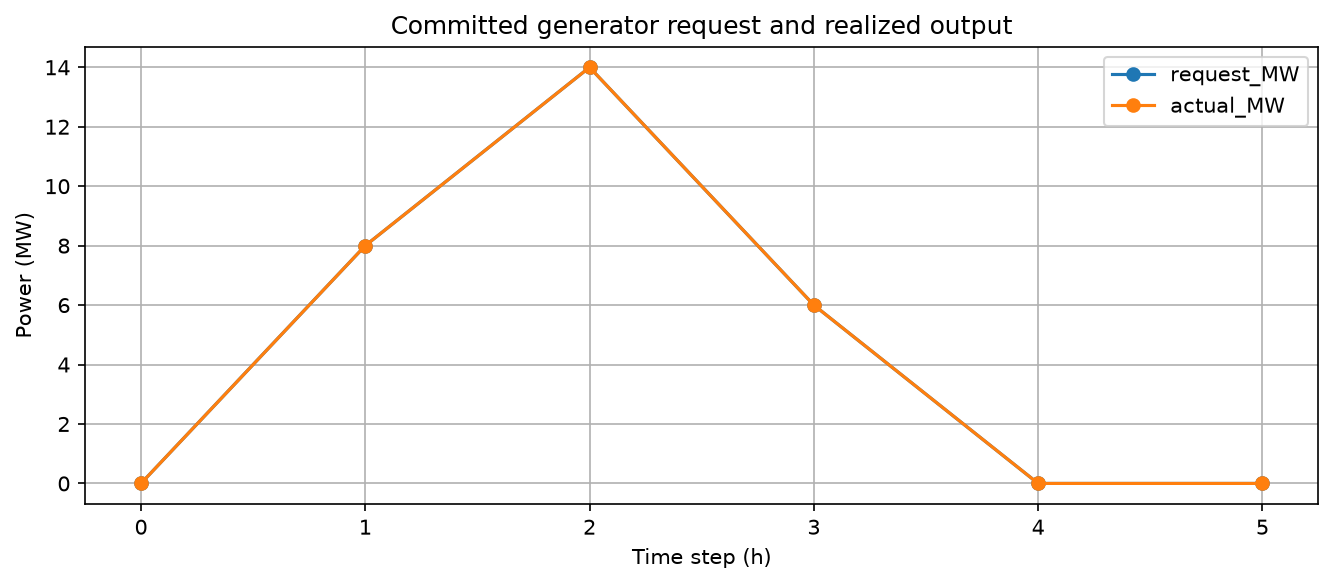

In [8]:
ax = commit_df.plot(x="hour", y=["request_MW", "actual_MW"], marker="o", figsize=(9, 4))
ax.set_xlabel("Time step (h)")
ax.set_ylabel("Power (MW)")
ax.set_title("Committed generator request and realized output")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** Realized output respects commitment state, minimum stable generation, ramp limits, and minimum up/down times. Startup penalties can be added to chronological economics.

## 4. Published benchmark KPIs

In [9]:
kpis = pd.Series(
    {
        "served energy (MWh)": result.getServedEnergyMWh(),
        "unmet energy (MWh)": result.getUnmetEnergyMWh(),
        "curtailed energy (MWh)": result.getCurtailedEnergyMWh(),
        "operating cost": result.getOperatingCost(),
        "CO2-equivalent (kg)": result.getCo2EmissionsKg(),
    }
)
kpis


Out[9]: 
served energy (MWh)         312.0
unmet energy (MWh)            0.0
curtailed energy (MWh)      196.0
operating cost            15120.0
CO2-equivalent (kg)       75600.0
dtype: float64


## Validation checks

The assertions below lock the engineering balances and benchmark values used in the interpretation.


In [10]:
assert abs(result.getServedEnergyMWh() - 312.0) < 1e-9
assert abs(result.getUnmetEnergyMWh()) < 1e-9
assert abs(result.getCurtailedEnergyMWh() - 196.0) < 1e-9
assert abs(result.getOperatingCost() - 15120.0) < 1e-9
assert abs(result.getCo2EmissionsKg() - 75600.0) < 1e-9
assert (
    interval_df["critical_MW"] + interval_df["flexible_MW"] - interval_df["served_MW"]
).abs().max() < 1e-9
assert commit_df["actual_MW"].between(0.0, 15.0).all()

validation = pd.Series(
    {
        "served energy (MWh)": result.getServedEnergyMWh(),
        "unmet energy (MWh)": result.getUnmetEnergyMWh(),
        "curtailed energy (MWh)": result.getCurtailedEnergyMWh(),
        "operating cost": result.getOperatingCost(),
        "CO₂ emissions (kg)": result.getCo2EmissionsKg(),
    }
)
validation


Out[10]: 
served energy (MWh)         312.0
unmet energy (MWh)            0.0
curtailed energy (MWh)      196.0
operating cost            15120.0
CO₂ emissions (kg)        75600.0
dtype: float64


## Summary

The notebook demonstrates how steady-state process/energy calculations become a chronological operating study. Professional extensions may add stochastic wind scenarios, maintenance availability, battery degradation, reserve criteria, and mixed-integer scheduling.